In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset limpio
df = pd.read_csv('../data/crude_oil_clean.csv')

# Eliminar clase con muy pocas muestras
df = df[df['TIPO_CRUDO'] != 'Extra pesado'].copy()

# Features y variable objetivo
features = ['SGRAV_CRUD', 'SRC', 'CRN', 'SU100', 
            'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL', 
            'GAS_NP_VOL', 'RESDUM_VOL']

X = df[features]
y = df['TIPO_CRUDO']

# Filtrar outliers extremos de viscosidad
X = X[X['SU100'] < 2000].copy()
y = y[X.index]

# Encodear variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Clases:", le.classes_)
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print("\nDistribución en train:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

Clases: ['Liviano' 'Mediano' 'Pesado']
Train: 7079 muestras
Test:  1770 muestras

Distribución en train:
  Liviano: 5450
  Mediano: 1178
  Pesado: 451


RANDOM FOREST — Resultados
              precision    recall  f1-score   support

     Liviano       1.00      1.00      1.00      1363
     Mediano       1.00      1.00      1.00       294
      Pesado       1.00      1.00      1.00       113

    accuracy                           1.00      1770
   macro avg       1.00      1.00      1.00      1770
weighted avg       1.00      1.00      1.00      1770



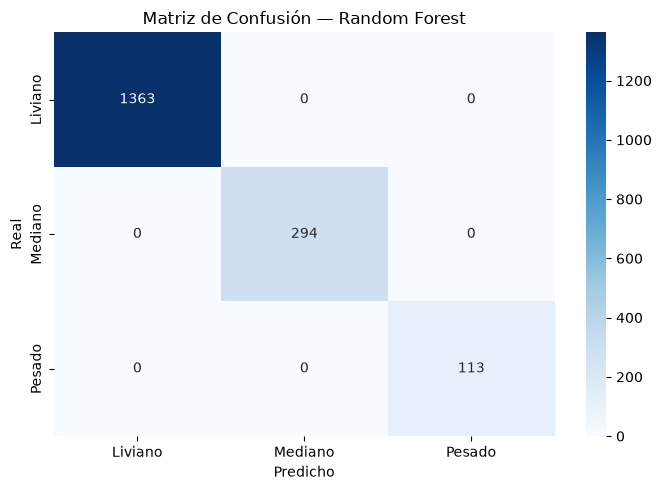

In [2]:
# Modelo 1: Random Forest (baseline)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # compensa el desbalance de clases
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("=" * 50)
print("RANDOM FOREST — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusión — Random Forest')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

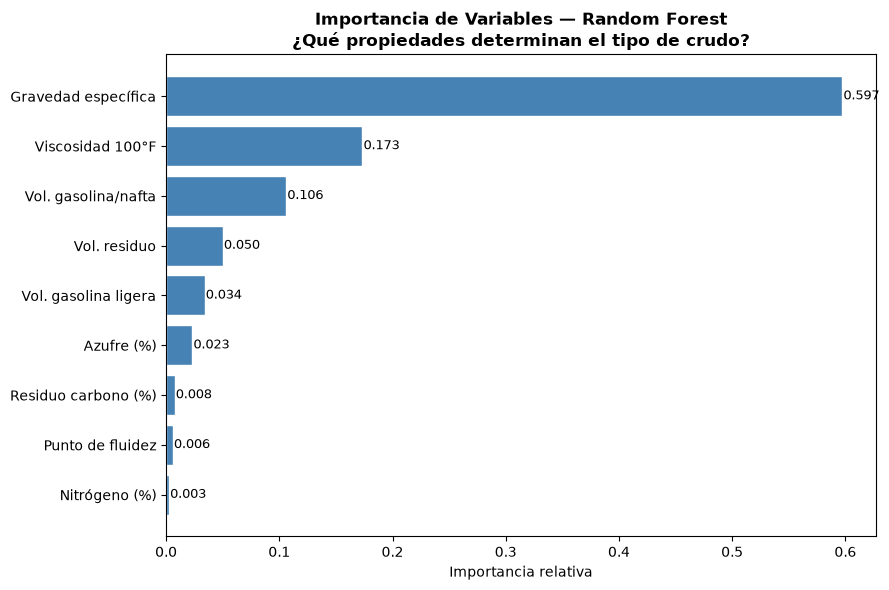

In [3]:
# Importancia de features — Random Forest
importancias = pd.DataFrame({
    'feature': features,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=True)

nombres_legibles = {
    'SGRAV_CRUD': 'Gravedad específica',
    'SRC': 'Azufre (%)',
    'CRN': 'Nitrógeno (%)',
    'SU100': 'Viscosidad 100°F',
    'POUR_POINT': 'Punto de fluidez',
    'CAR_CR_WT': 'Residuo carbono (%)',
    'LT_GAS_VOL': 'Vol. gasolina ligera',
    'GAS_NP_VOL': 'Vol. gasolina/nafta',
    'RESDUM_VOL': 'Vol. residuo'
}
importancias['feature'] = importancias['feature'].map(nombres_legibles)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importancias['feature'], importancias['importancia'],
               color='steelblue', edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest\n¿Qué propiedades determinan el tipo de crudo?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
for bar, val in zip(bars, importancias['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

GRADIENT BOOSTING — Predicción Dulce vs Agrio
(sin usar azufre como feature)
                precision    recall  f1-score   support

Dulce (<0.5%S)       0.91      0.94      0.93      1283
Agrio (≥0.5%S)       0.83      0.75      0.79       489

      accuracy                           0.89      1772
     macro avg       0.87      0.85      0.86      1772
  weighted avg       0.89      0.89      0.89      1772

AUC-ROC: 0.9416


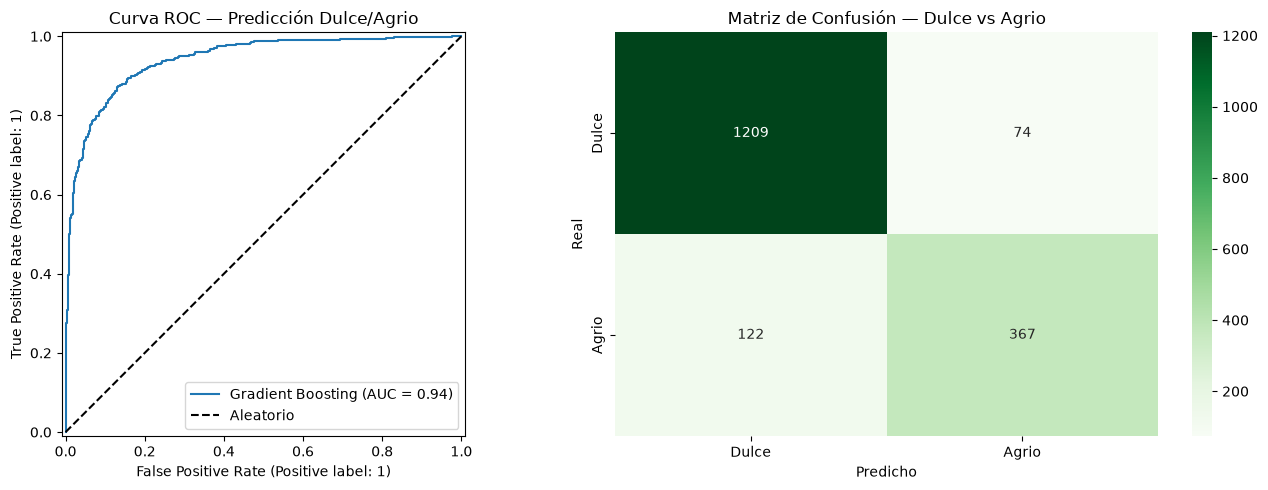

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Nueva tarea: predecir si el crudo es dulce o agrio
# SIN usar el azufre como feature — el modelo debe inferirlo

df2 = pd.read_csv('../data/crude_oil_clean.csv')
df2 = df2[df2['SU100'] < 2000].copy()

# Variable objetivo: dulce=0, agrio=1
df2['DULCE_AGRIO'] = (df2['SRC'] >= 0.5).astype(int)

# Features SIN azufre
features2 = ['API_CRUDE', 'SGRAV_CRUD', 'CRN', 'SU100',
             'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL',
             'GAS_NP_VOL', 'RESDUM_VOL']

X2 = df2[features2]
y2 = df2['DULCE_AGRIO']

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

# Modelo: Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X2_train, y2_train)
y2_pred = gb_model.predict(X2_test)
y2_proba = gb_model.predict_proba(X2_test)[:, 1]

print("=" * 55)
print("GRADIENT BOOSTING — Predicción Dulce vs Agrio")
print("(sin usar azufre como feature)")
print("=" * 55)
print(classification_report(y2_test, y2_pred,
      target_names=['Dulce (<0.5%S)', 'Agrio (≥0.5%S)']))
print(f"AUC-ROC: {roc_auc_score(y2_test, y2_proba):.4f}")

# Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y2_test, y2_proba,
    name='Gradient Boosting', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', label='Aleatorio')
axes[0].set_title('Curva ROC — Predicción Dulce/Agrio')
axes[0].legend()

# Matriz de confusión
cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dulce','Agrio'],
            yticklabels=['Dulce','Agrio'], ax=axes[1])
axes[1].set_title('Matriz de Confusión — Dulce vs Agrio')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../data/modelo_dulce_agrio.png', dpi=150, bbox_inches='tight')
plt.show()